In [6]:
from pathlib import Path
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Transforms
# -----------------------------
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# -----------------------------
# Dataset
# -----------------------------
data_dir = Path(r"C:\MOAD\MOAD_split_224")

train_dataset = datasets.ImageFolder(data_dir / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(data_dir / "val", transform=val_transform)
test_dataset  = datasets.ImageFolder(data_dir / "test", transform=val_transform)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# -----------------------------
# Model (MobileNetV2)
# -----------------------------
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(train_dataset.classes))

model = model.to(device)

# -----------------------------
# Loss + Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

# -----------------------------
# Training
# -----------------------------
import time
import torch

MAX_EPOCHS = 25
epoch = 0
losses = []
best_loss = float("inf")
best_val_acc = 0.0

if device.type == "cuda":
    torch.cuda.synchronize()
start_time = time.perf_counter()

while epoch < MAX_EPOCHS:
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / train_total
    train_acc = train_correct / train_total
    losses.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_mobilenetv2.pth")

    print(
        f"Epoch {epoch:3d} | "
        f"loss {epoch_loss:.4f} | "
        f"train_acc {train_acc:.4f} | "
        f"val_acc {val_acc:.4f}"
    )

    epoch += 1

if device.type == "cuda":
    torch.cuda.synchronize()
end_time = time.perf_counter()

print("Training complete.")
print(f"Best training loss: {best_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Training took {end_time - start_time:.4f} seconds")

Using device: cuda
Train size: 1354
Val size: 292
Test size: 292
Epoch   0 | loss 3.3142 | train_acc 0.2223 | val_acc 0.5000
Epoch   1 | loss 2.3972 | train_acc 0.5916 | val_acc 0.6062
Epoch   2 | loss 1.7971 | train_acc 0.7526 | val_acc 0.6644
Epoch   3 | loss 1.3889 | train_acc 0.8139 | val_acc 0.7192
Epoch   4 | loss 1.1308 | train_acc 0.8516 | val_acc 0.7260
Epoch   5 | loss 0.9498 | train_acc 0.8811 | val_acc 0.7603
Epoch   6 | loss 0.8083 | train_acc 0.8988 | val_acc 0.7568
Epoch   7 | loss 0.7299 | train_acc 0.9062 | val_acc 0.7671
Epoch   8 | loss 0.6513 | train_acc 0.9210 | val_acc 0.7534
Epoch   9 | loss 0.5693 | train_acc 0.9291 | val_acc 0.7397
Epoch  10 | loss 0.5160 | train_acc 0.9549 | val_acc 0.7397
Epoch  11 | loss 0.4803 | train_acc 0.9365 | val_acc 0.7568
Epoch  12 | loss 0.4512 | train_acc 0.9431 | val_acc 0.7603
Epoch  13 | loss 0.4059 | train_acc 0.9490 | val_acc 0.7671
Epoch  14 | loss 0.3769 | train_acc 0.9660 | val_acc 0.7740
Epoch  15 | loss 0.3466 | train_acc

In [7]:
# Load best model
model.load_state_dict(torch.load("best_mobilenetv2.pth"))
model.eval()

all_preds = []
all_labels = []

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 77.05%


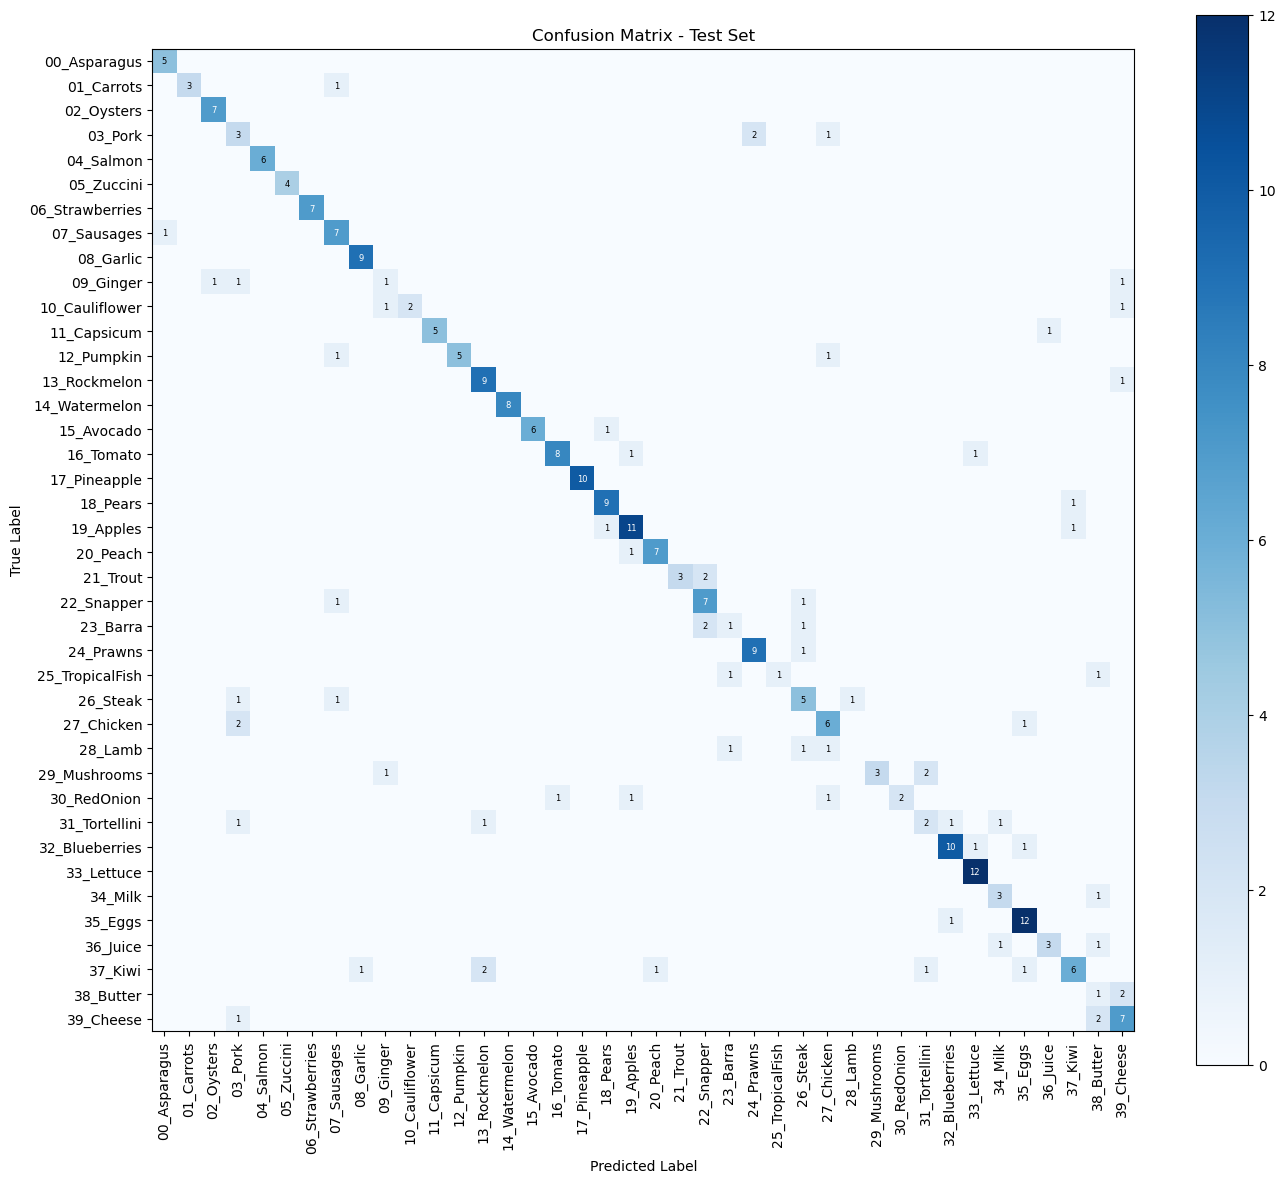

In [8]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

classes = test_dataset.classes
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        if value > 0:
            plt.text(
                j, i, str(value),
                ha="center",
                va="center",
                color="white" if value > cm.max() / 2 else "black",
                fontsize=6
            )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()